# 6 · Are inconsistent reviews more or less helpful?

Helpful votes depend heavily on **exposure**: older reviews and reviews of popular products are seen
more often. The comparisons below therefore run from simplest to most controlled.

1. **Descriptive:** consistent vs inconsistent reviews *with the same star rating*
2. **Regression:** Poisson pseudo-maximum-likelihood on the vote count (robust SEs), and logit on
   receiving ≥1 vote. Controls cover stars, length, title, photos, verified status, year fixed effects,
   product popularity and product average rating.
3. **Within-product:** a linear probability model with product fixed effects, which compares reviews
   of the same product only
4. **Prediction:** a re-run of Kung et al.'s (2024) task, predicting ≥1 helpful vote, with the
   target leakage in their reviewer-history feature removed. We then test whether consistency
   features add predictive power.

In [1]:
import sys

sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

from common import (BLUE, DIRECTION_COLORS, HIGH_NEG, INK_2, LOW_POS, MUTED, NEUTRAL, SURFACE, load,
                    rate_table, ratio_table, savefig, set_style)

set_style()
df = load()
df["year_c"] = df.year.clip(lower=2012)  # pool the sparse early years
polar = df[df.polar_rating & df.avg_rating.notna()].copy()
polar["incons_high"] = (polar.inconsistent & (polar.rating >= 4)).astype(int)
polar["incons_low"] = (polar.inconsistent & (polar.rating <= 2)).astype(int)
for c in ["has_title", "has_images", "verified_purchase", "has_helpful"]:
    polar[c] = polar[c].astype(int)
for c in ["log_words", "log_rating_number", "avg_rating"]:
    polar[f"z_{c}"] = (polar[c] - polar[c].mean()) / polar[c].std()
print(f"{len(polar):,} polar reviews with product metadata")

638,532 polar reviews with product metadata


## 1 · Descriptive: same stars, consistent vs inconsistent

status,consistent (≥1 vote),inconsistent (≥1 vote),consistent (mean votes),inconsistent (mean votes)
rating,,,,
1.0,0.2988,0.3515,0.945,1.665
2.0,0.2640,0.2938,0.725,1.005
4.0,0.2719,0.2787,0.933,0.903
5.0,0.2590,0.3033,0.952,1.750


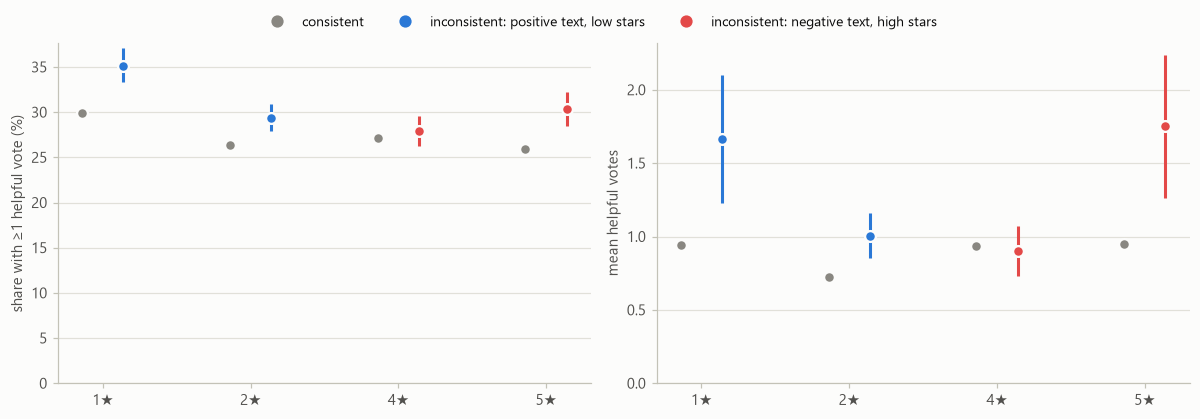

In [2]:
polar["status"] = np.where(polar.inconsistent, "inconsistent", "consistent")
share = rate_table(polar, ["rating", "status"], "has_helpful")
means = (polar.groupby(["rating", "status"]).helpful_vote.agg(["mean", "std", "size"]).reset_index())
means["lo"] = means["mean"] - 1.96 * means["std"] / np.sqrt(means["size"])
means["hi"] = means["mean"] + 1.96 * means["std"] / np.sqrt(means["size"])


def mark_color(rating, status):
    if status == "consistent":
        return MUTED
    return DIRECTION_COLORS[HIGH_NEG if rating >= 4 else LOW_POS]


fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, t, col, scale, label in [(axes[0], share, "rate", 100, "share with ≥1 helpful vote (%)"),
                                 (axes[1], means, "mean", 1, "mean helpful votes")]:
    stars = [1, 2, 4, 5]
    for i, star in enumerate(stars):
        for j, status in enumerate(["consistent", "inconsistent"]):
            r = t[(t.rating == star) & (t.status == status)].iloc[0]
            x = i + (j - 0.5) * 0.28
            c = mark_color(star, status)
            ax.vlines(x, scale * r.lo, scale * r.hi, color=c, linewidth=2)
            ax.scatter(x, scale * r[col], color=c, s=50, zorder=3, edgecolor=SURFACE, linewidth=1.5)
    ax.set_xticks(range(4), [f"{s}★" for s in stars])
    ax.set_ylim(bottom=0)
    ax.set_ylabel(label)
    ax.grid(axis="x", visible=False)
handles = [plt.Line2D([], [], marker="o", linestyle="", color=MUTED, markersize=7, label="consistent"),
           plt.Line2D([], [], marker="o", linestyle="", color=DIRECTION_COLORS[LOW_POS], markersize=7,
                      label=f"inconsistent: {LOW_POS}"),
           plt.Line2D([], [], marker="o", linestyle="", color=DIRECTION_COLORS[HIGH_NEG], markersize=7,
                      label=f"inconsistent: {HIGH_NEG}")]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.06))
fig.tight_layout()
savefig(fig, "06_helpfulness_by_star")
share.pivot(index="rating", columns="status", values="rate").round(4).join(
    means.pivot(index="rating", columns="status", values="mean").round(3), lsuffix=" (≥1 vote)",
    rsuffix=" (mean votes)")

### A graded view: how many of the three models flag the review?

In [3]:
polar["star_group"] = np.where(polar.rating >= 4, "4–5★", "1–2★")
graded = polar.groupby(["star_group", "n_models_reversed"]).agg(
    reviews=("has_helpful", "size"), share_helpful=("has_helpful", "mean"), mean_votes=("helpful_vote", "mean"))
graded.round(3)

reviews  share_helpful  mean_votes
star_group n_models_reversed                                    
1–2★       0                    79337          0.271       0.785
           1                    34981          0.302       0.946
           2                    24145          0.329       1.126
           3                     5026          0.318       1.292
4–5★       0                   466706          0.259       0.929
           1                    21479          0.308       1.376
           2                     5136          0.300       1.300
           3                     1722          0.270       1.204

## 2 · Regression with controls

The tables report incidence-rate ratios (Poisson PML) and odds ratios (logit) for the two
inconsistency indicators. The reference group is consistent reviews with the same star rating.

In [4]:
controls = ("C(rating) + z_log_words + has_title + has_images + verified_purchase + C(year_c)"
            " + z_log_rating_number + z_avg_rating")
poisson = smf.glm(f"helpful_vote ~ incons_high + incons_low + {controls}", polar,
                  family=sm.families.Poisson()).fit(cov_type="HC1")
logit = smf.logit(f"has_helpful ~ incons_high + incons_low + {controls}", polar).fit(disp=0)
keep = ["incons_high", "incons_low", "z_log_words", "has_images", "verified_purchase", "has_title",
        "z_log_rating_number"]
names = {"incons_high": f"inconsistent: {HIGH_NEG}", "incons_low": f"inconsistent: {LOW_POS}",
         "z_log_words": "longer review (+1 SD)", "has_images": "includes photos",
         "verified_purchase": "verified purchase", "has_title": "user-written title",
         "z_log_rating_number": "more popular product (+1 SD)"}
regression = pd.concat({"Poisson: rate ratio for votes": ratio_table(poisson, "ratio").loc[keep],
                        "Logit: odds ratio for ≥1 vote": ratio_table(logit, "ratio").loc[keep]}, axis=1)
regression.index = [names[k] for k in keep]
regression.round(3)

Poisson: rate ratio for votes         \
                                                                ratio     lo   
inconsistent: negative text, high stars                         1.422  1.180   
inconsistent: positive text, low stars                          1.132  0.968   
longer review (+1 SD)                                           2.261  2.215   
includes photos                                                 2.664  2.551   
verified purchase                                               1.710  1.628   
user-written title                                              0.825  0.783   
more popular product (+1 SD)                                    1.388  1.360   

                                                       \
                                            hi      p   
inconsistent: negative text, high stars  1.714  0.000   
inconsistent: positive text, low stars   1.325  0.121   
longer review (+1 SD)                    2.308  0.000   
includes photos                          2.781  0.000   
verified purchase                        1.795  0.000   
user-written title                       0.869  0.000   
more popular product (+1 SD)             1.417  0.000   

                                        Logit: odds ratio for ≥1 vote         \
                                                                ratio     lo   
inconsistent: negative text, high stars                         1.149  1.079   
inconsistent: positive text, low stars                          0.970  0.915   
longer review (+1 SD)                                           1.936  1.921   
includes photos                                                 2.216  2.174   
verified purchase                                               1.660  1.626   
user-written title                                              0.875  0.853   
more popular product (+1 SD)                                    1.026  1.019   

                                                       
                                            hi      p  
inconsistent: negative text, high stars  1.225  0.000  
inconsistent: positive text, low stars   1.029  0.319  
longer review (+1 SD)                    1.950  0.000  
includes photos                          2.260  0.000  
verified purchase                        1.695  0.000  
user-written title                       0.897  0.000  
more popular product (+1 SD)             1.032  0.000

### Robustness: the high-precision flag

The same models are refit with `inconsistent_confident` in place of the working flag. Its audited
precision is higher, so if genuine inconsistency drives the helpfulness gap, the estimates should
hold up or grow.

In [5]:
polar["incons_high"] = (polar.inconsistent_confident & (polar.rating >= 4)).astype(int)
polar["incons_low"] = (polar.inconsistent_confident & (polar.rating <= 2)).astype(int)
poisson_c = smf.glm(f"helpful_vote ~ incons_high + incons_low + {controls}", polar,
                    family=sm.families.Poisson()).fit(cov_type="HC1")
logit_c = smf.logit(f"has_helpful ~ incons_high + incons_low + {controls}", polar).fit(disp=0)
flags = ["incons_high", "incons_low"]
robust = pd.concat({"Poisson: rate ratio for votes": ratio_table(poisson_c, "ratio").loc[flags],
                    "Logit: odds ratio for ≥1 vote": ratio_table(logit_c, "ratio").loc[flags]}, axis=1)
robust.index = [f"confident {names[k]}" for k in flags]
print(f"confident flags: {polar.incons_high.sum():,} high-star, {polar.incons_low.sum():,} low-star")
# restore the working flags for the rest of the notebook
polar["incons_high"] = (polar.inconsistent & (polar.rating >= 4)).astype(int)
polar["incons_low"] = (polar.inconsistent & (polar.rating <= 2)).astype(int)
robust.round(3)

confident flags: 1,939 high-star, 2,181 low-star


Poisson: rate ratio for votes  \
                                                                          ratio   
confident inconsistent: negative text, high stars                         1.362   
confident inconsistent: positive text, low stars                          1.292   

                                                                        \
                                                      lo     hi      p   
confident inconsistent: negative text, high stars  0.952  1.949  0.091   
confident inconsistent: positive text, low stars   0.918  1.819  0.142   

                                                  Logit: odds ratio for ≥1 vote  \
                                                                          ratio   
confident inconsistent: negative text, high stars                         1.145   
confident inconsistent: positive text, low stars                          0.986   

                                                                        
                                                      lo     hi      p  
confident inconsistent: negative text, high stars  1.030  1.273  0.012  
confident inconsistent: positive text, low stars   0.893  1.088  0.775

## 3 · Within the same product: product fixed effects

This is a linear probability model for ≥1 helpful vote. Every variable is demeaned within product, and
standard errors are clustered by product. Only products with at least 10 polar reviews are used.
Coefficients are **percentage-point** differences in the chance of a helpful vote.

In [6]:
import patsy

fe = polar[polar.groupby("parent_asin").review_id.transform("size") >= 10].copy()
y, X = patsy.dmatrices(f"has_helpful ~ incons_high + incons_low + C(rating) + z_log_words + has_title"
                       f" + has_images + verified_purchase + C(year_c)", fe, return_type="dataframe")
X = X.drop(columns="Intercept")
groups = fe.parent_asin.to_numpy()
y_dm = y - y.groupby(groups).transform("mean")
X_dm = X - X.groupby(groups).transform("mean")
lpm = sm.OLS(y_dm, X_dm).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(groups)[0]})
fe_table = pd.DataFrame({"pp_change": 100 * lpm.params, "lo": 100 * lpm.conf_int()[0],
                         "hi": 100 * lpm.conf_int()[1], "p": lpm.pvalues}).loc[["incons_high", "incons_low"]]
fe_table.index = [names[k] for k in fe_table.index]
print(f"{len(fe):,} reviews of {fe.parent_asin.nunique():,} products; "
      f"baseline share with ≥1 vote: {fe.has_helpful.mean():.1%}")
fe_table.round(3)

411,094 reviews of 12,062 products; baseline share with ≥1 vote: 27.5%


,pp_change,lo,hi,p
"inconsistent: negative text, high stars",1.379,-0.032,2.791,0.055
"inconsistent: positive text, low stars",0.849,-0.549,2.246,0.234


## 4 · Re-running the helpful-vote prediction task from Kung et al. (2024)

**The leak.** Kung et al.'s strongest feature was each reviewer's average helpful votes *across all
their reviews*, which includes the review being predicted. Most reviewers wrote one review, so for
them this feature *is* the target. We rebuild it from **earlier reviews only**.

We use the paper's binary target, ≥1 helpful vote, on all reviews including 3★, with a random 80/20
split and gradient boosting. Kung et al.'s best reported accuracy was 0.969.

majority-class accuracy (always predict 'no helpful vote'): 0.733


,accuracy,ROC AUC,average precision
Kung et al. features (leaky reviewer history),0.969,0.992,0.966
"Kung et al. features, leak-free",0.743,0.625,0.404
+ review & product features,0.767,0.743,0.545
+ rating–sentiment consistency,0.767,0.741,0.542


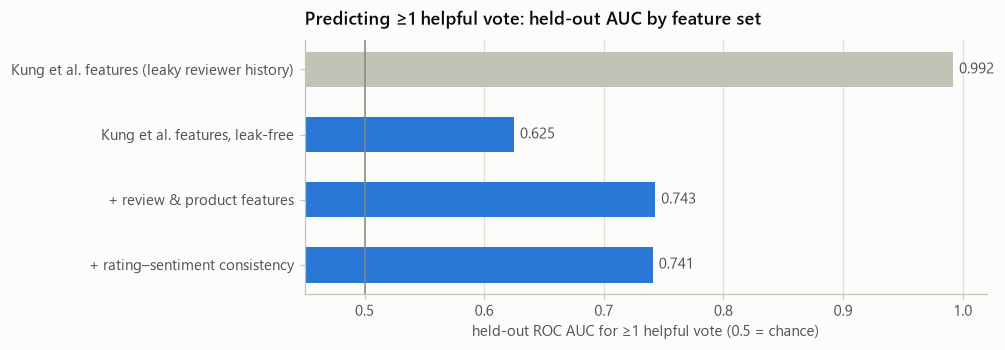

In [7]:
df["has_helpful_int"] = df.has_helpful.astype(int)
paper_leaky = ["user_mean_helpful_all", "n_images", "timestamp"]
paper_clean = ["user_prior_mean_helpful", "n_images", "timestamp"]
review = ["log_words", "has_title", "verified_purchase", "rating", "log_rating_number", "avg_rating",
          "user_n_reviews"]
consistency = ["inconsistent", "n_models_reversed", "discrepancy", "text_score", "vader", "textblob", "roberta"]
feature_sets = {
    "Kung et al. features (leaky reviewer history)": paper_leaky,
    "Kung et al. features, leak-free": paper_clean,
    "+ review & product features": paper_clean + review,
    "+ rating–sentiment consistency": paper_clean + review + consistency,
}
idx_tr, idx_te = train_test_split(df.index, test_size=0.2, random_state=0, stratify=df.has_helpful)
y_tr, y_te = df.loc[idx_tr, "has_helpful_int"], df.loc[idx_te, "has_helpful_int"]
results = {}
for name, feats in feature_sets.items():
    X = df[feats].astype(float)
    m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, random_state=0).fit(X.loc[idx_tr], y_tr)
    p = m.predict_proba(X.loc[idx_te])[:, 1]
    results[name] = {"accuracy": accuracy_score(y_te, p >= 0.5), "ROC AUC": roc_auc_score(y_te, p),
                     "average precision": average_precision_score(y_te, p)}
results = pd.DataFrame(results).T
majority = 1 - y_te.mean()
print(f"majority-class accuracy (always predict 'no helpful vote'): {majority:.3f}")

fig, ax = plt.subplots(figsize=(8, 3))
names_ = list(results.index)[::-1]
colors = [NEUTRAL if "leaky" in n else BLUE for n in names_]
ax.barh(names_, results.loc[names_, "ROC AUC"], height=0.55, color=colors)
for i, n in enumerate(names_):
    ax.text(results.loc[n, "ROC AUC"] + 0.005, i, f"{results.loc[n, 'ROC AUC']:.3f}", va="center", color=INK_2)
ax.axvline(0.5, color=MUTED, linewidth=1)
ax.set_xlim(0.45, 1.02)
ax.set_xlabel("held-out ROC AUC for ≥1 helpful vote (0.5 = chance)")
ax.set_title("Predicting ≥1 helpful vote: held-out AUC by feature set")
ax.grid(axis="y", visible=False)
savefig(fig, "06_prediction_auc")
results.round(3)